In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm, chi2

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.activations import softplus

from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras import initializers
import keras_tuner as kt
from tqdm import tqdm


data = pd.read_csv('returns_data.csv')
realized_df = pd.read_csv('realized_volatility.csv')
cond_df = pd.read_csv('conditional_volatility.csv')

In [67]:
data = data.rename(columns={'daily.returns': 'log_return', 'Date': 'date'})
cond_df = cond_df.rename(columns={'Conditional_Volatility': 'cond_var', 'Date': 'date'})
data['squared_return'] = data['log_return'] ** 2

In [68]:
realized_df['Realized_Volatility'] = np.sqrt(realized_df['Realized_Volatility'])

In [69]:
cond_df['cond_var']  = np.sqrt(cond_df['cond_var'])

In [70]:
print(realized_df.head())
print(cond_df.head())
print(data.head())

         Date  Realized_Volatility
0  2005-01-04             0.011740
1  2005-01-05             0.003634
2  2005-01-06             0.003500
3  2005-01-07             0.001432
4  2005-01-10             0.003417
         date  cond_var
0  2005-01-04  0.006530
1  2005-01-05  0.006528
2  2005-01-06  0.006527
3  2005-01-07  0.006525
4  2005-01-10  0.006523
         date  log_return  squared_return
0  2004-01-05    0.012319        0.000152
1  2004-01-06    0.001291        0.000002
2  2004-01-07    0.002364        0.000006
3  2004-01-08    0.004951        0.000025
4  2004-01-09   -0.008927        0.000080


In [71]:
realized_df.rename(columns={"Date": "date"}, inplace=True)

In [72]:
cond_df.rename(columns={"cond_var": "garch_vol"}, inplace=True)

In [ ]:
merged_df = data.merge(cond_df, on='date').merge(realized_df, on='date')

print(merged_df.head())

         date  log_return  squared_return  garch_vol  Realized_Volatility
0  2005-01-04   -0.011740        0.000138   0.006530             0.011740
1  2005-01-05   -0.003634        0.000013   0.006528             0.003634
2  2005-01-06    0.003500        0.000012   0.006527             0.003500
3  2005-01-07   -0.001432        0.000002   0.006525             0.001432
4  2005-01-10    0.003417        0.000012   0.006523             0.003417


In [74]:
merged_df[['log_return','garch_vol','squared_return','Realized_Volatility']] = 100*merged_df[['log_return','garch_vol','squared_return','Realized_Volatility']]

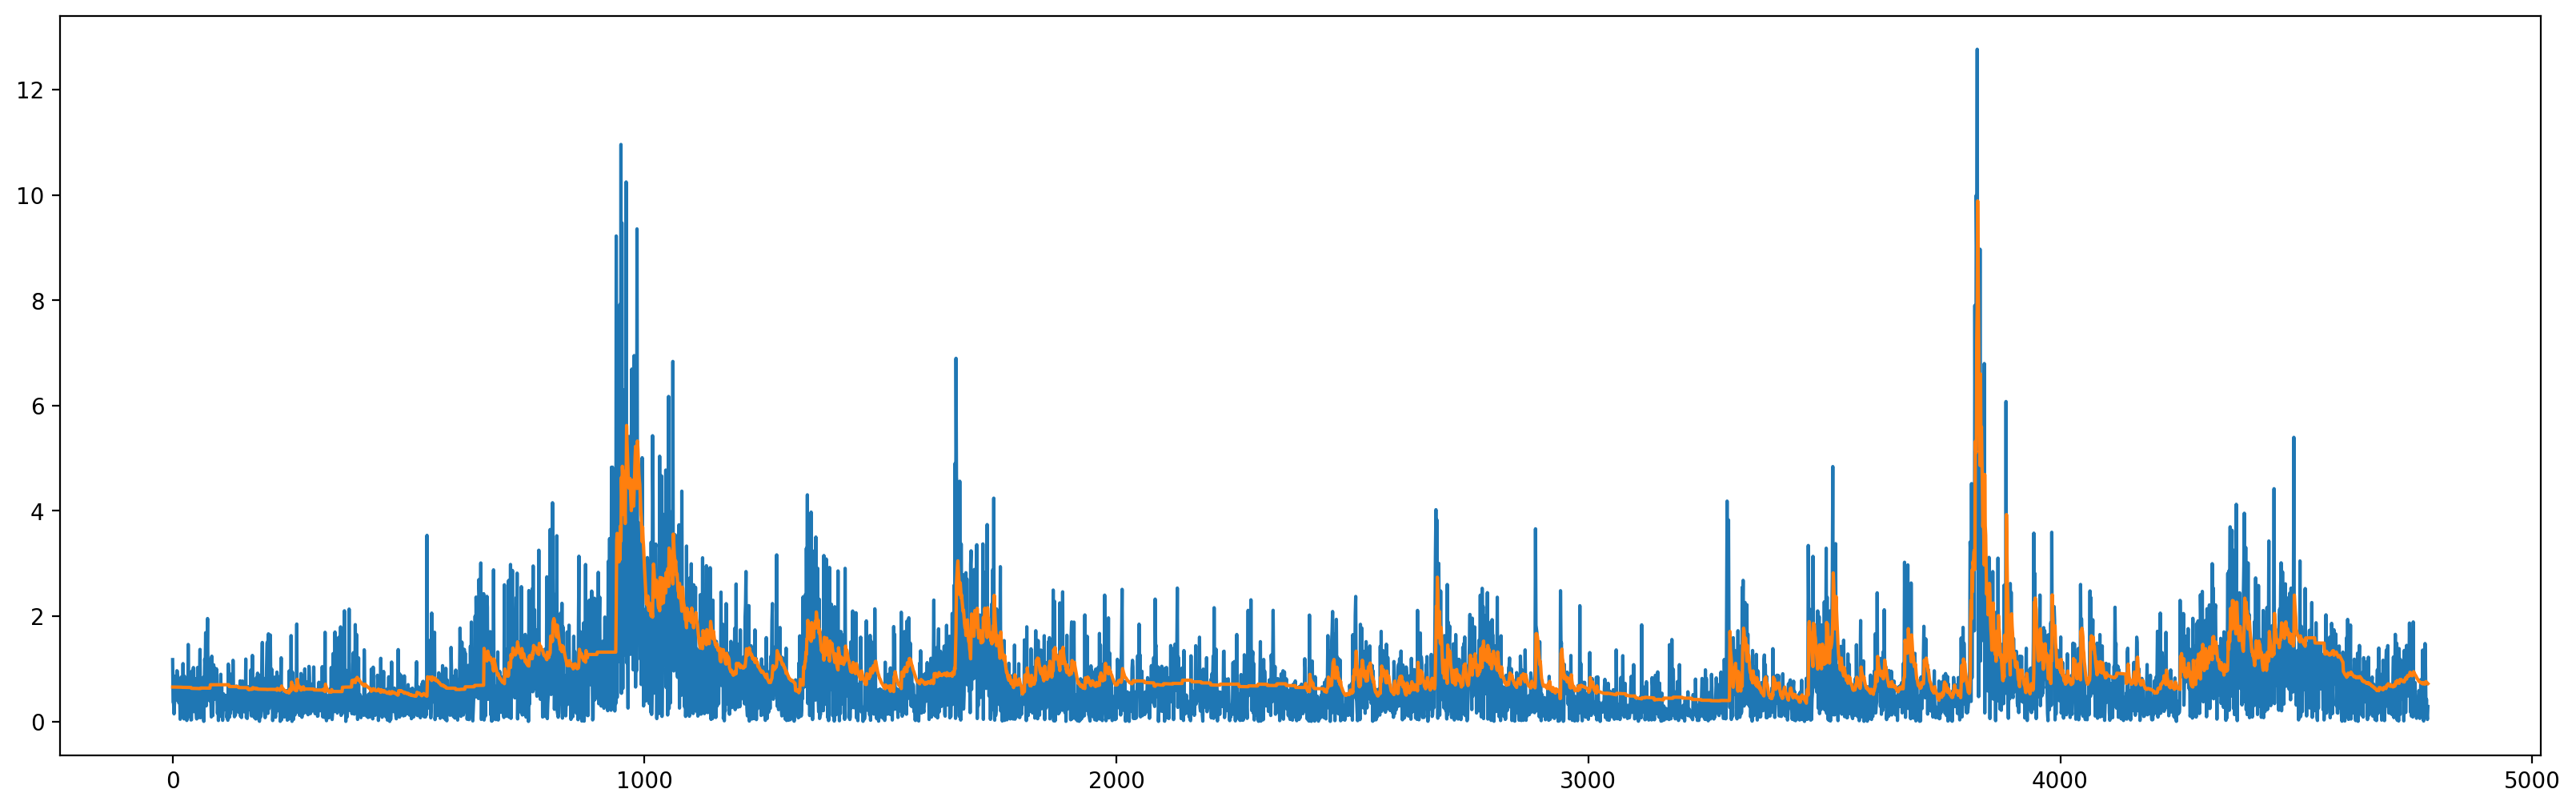

In [119]:
plt.subplots(figsize=(20, 6), dpi=200)
plt.plot(merged_df['Realized_Volatility'])
plt.plot(merged_df['garch_vol'])
plt.show()

# Main lstm prediction code with best hyperparameters

Window 3: MSE = 1.015885, MAE = 0.748538


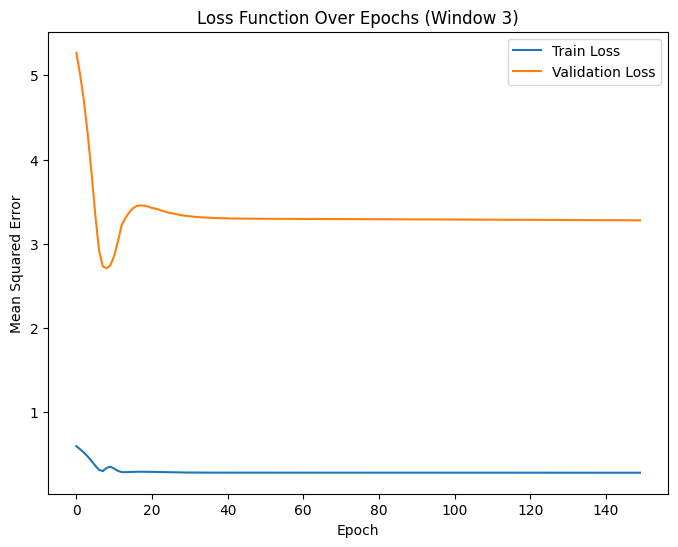

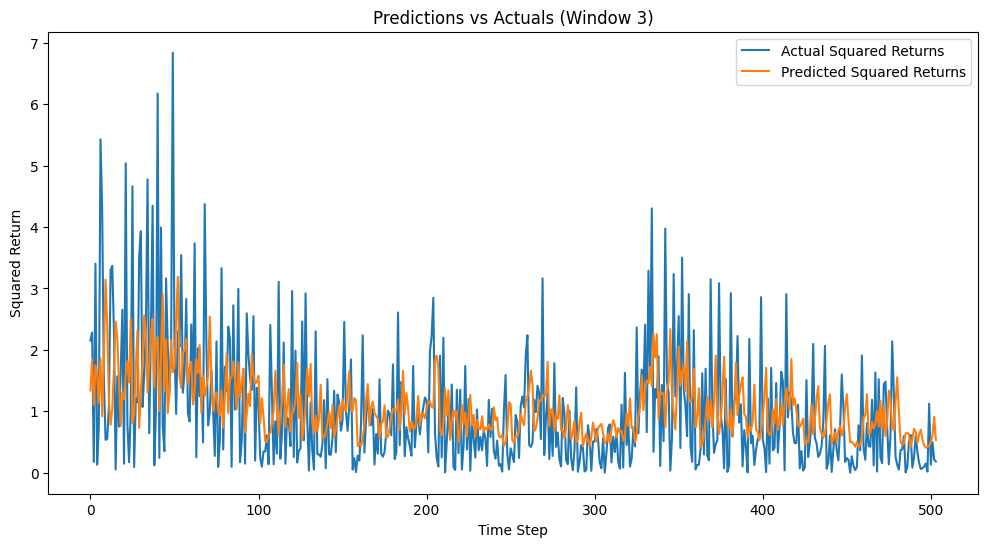

Window 507: MSE = 0.654537, MAE = 0.592937


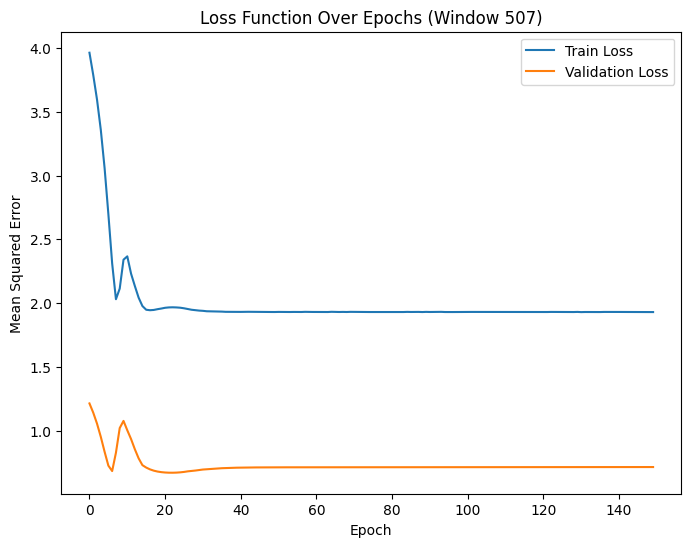

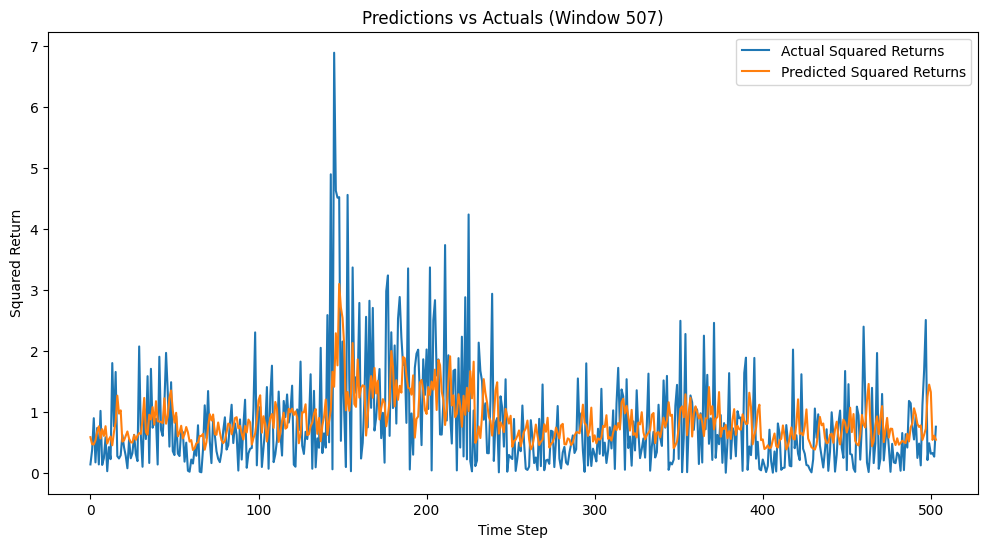

Window 1011: MSE = 0.216035, MAE = 0.368373


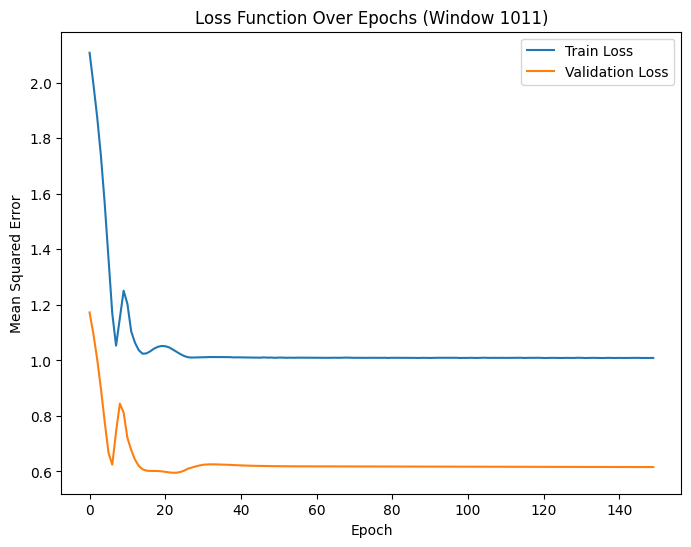

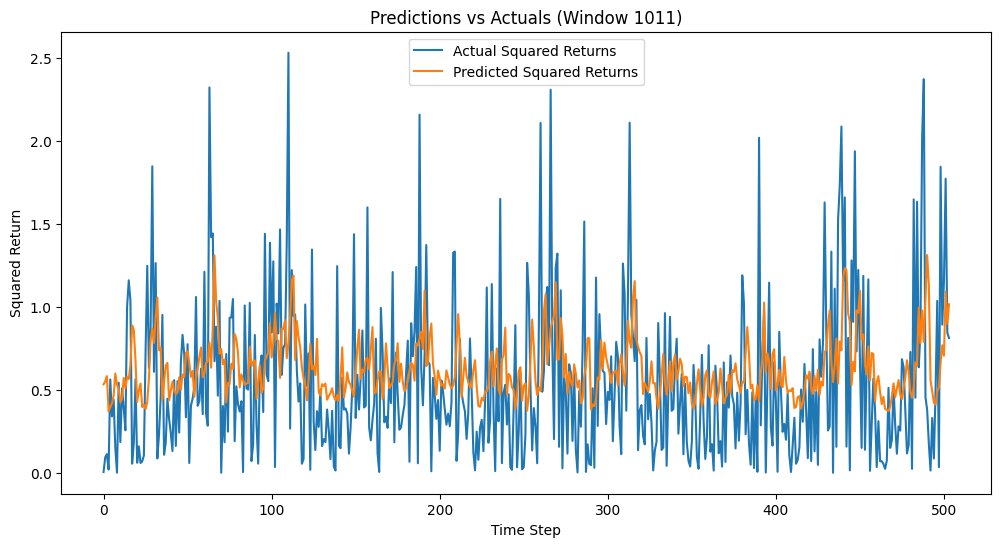

Window 1515: MSE = 0.362828, MAE = 0.442387


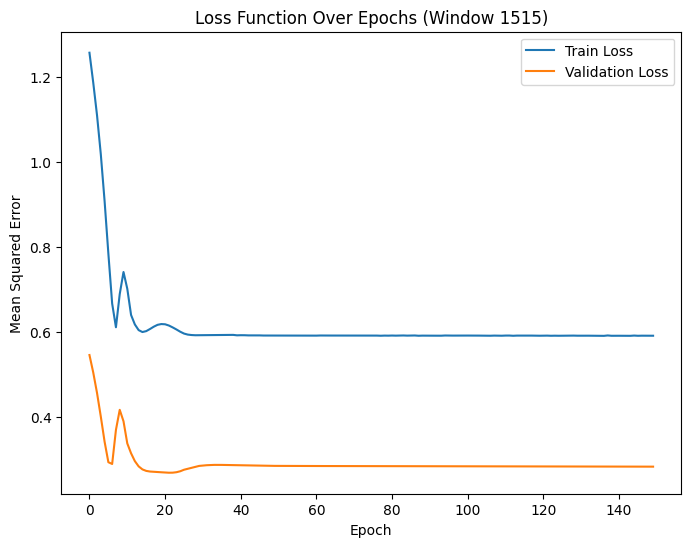

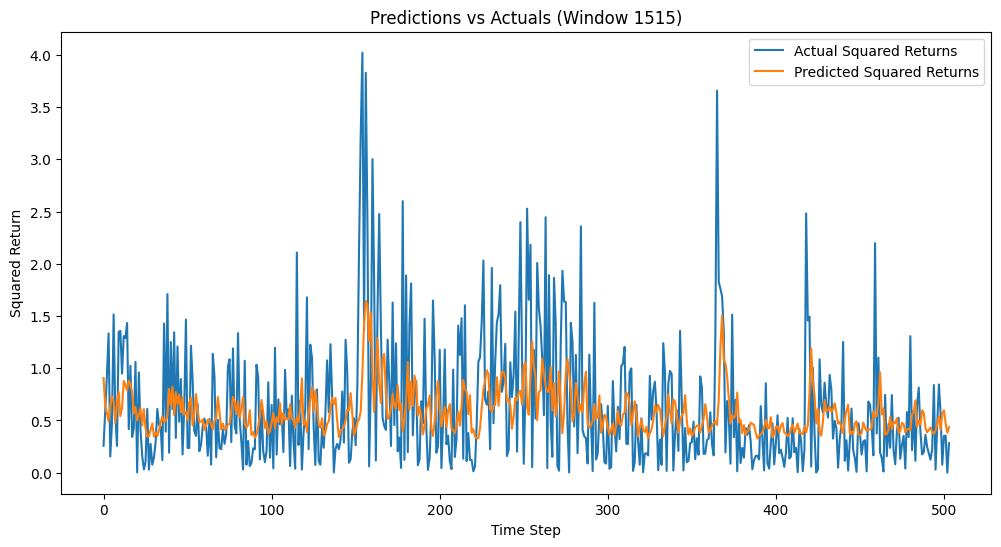

Window 2019: MSE = 0.366432, MAE = 0.414746


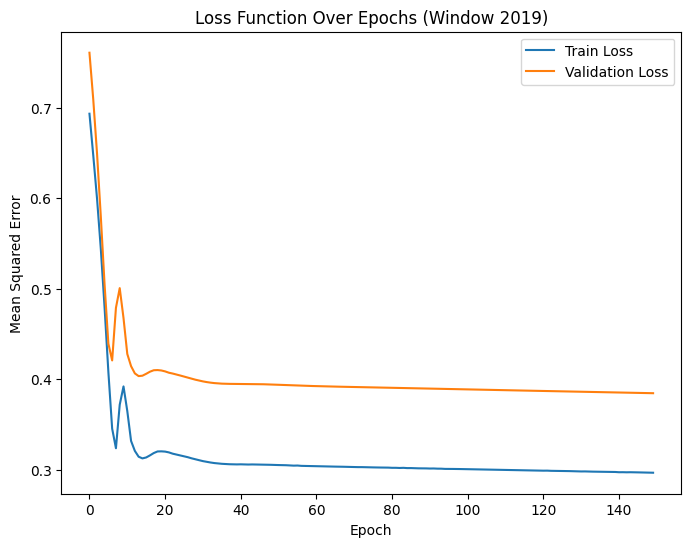

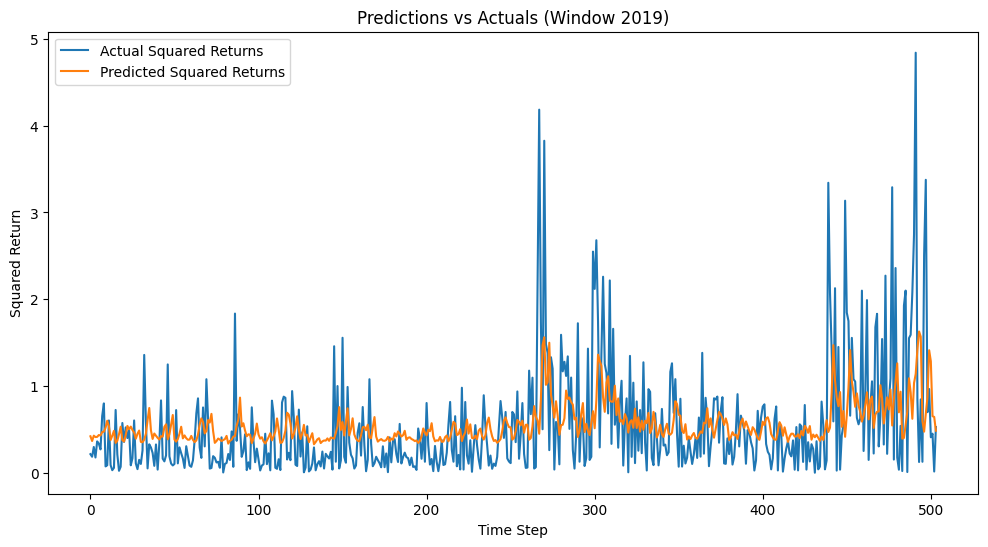

Window 2523: MSE = 1.248763, MAE = 0.597613


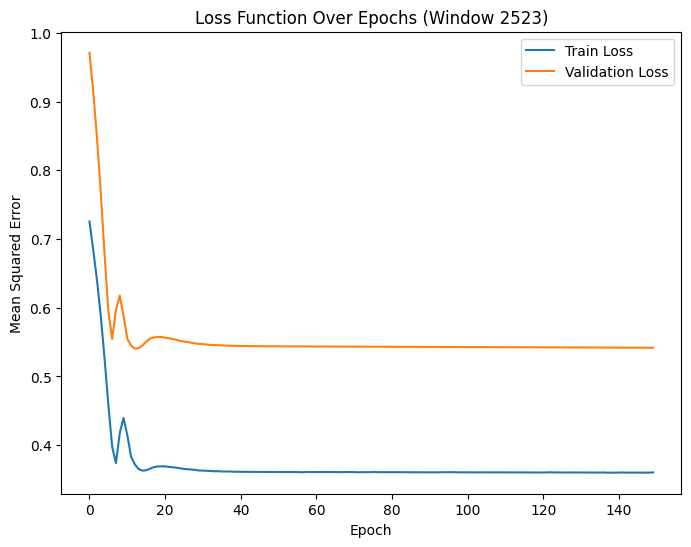

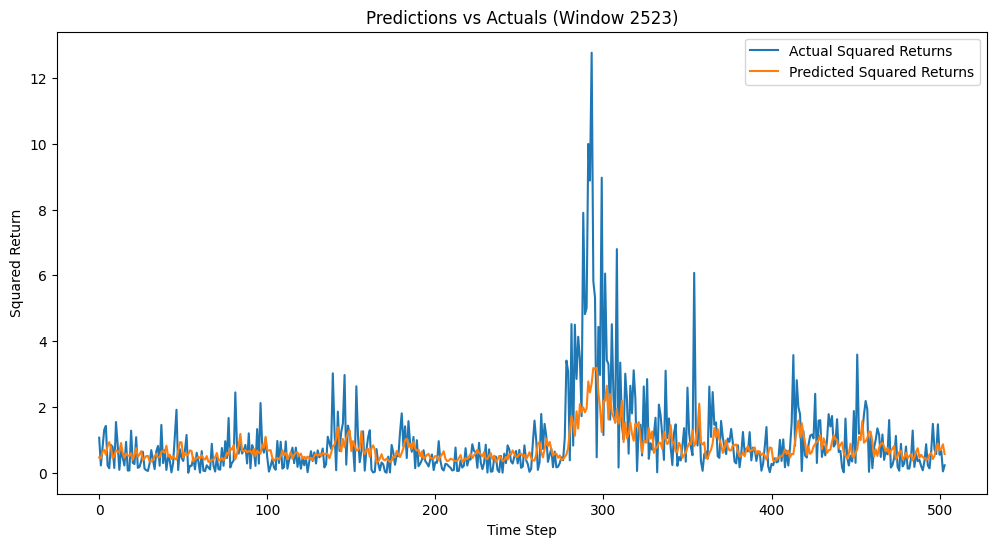

Window 3027: MSE = 0.681334, MAE = 0.633778


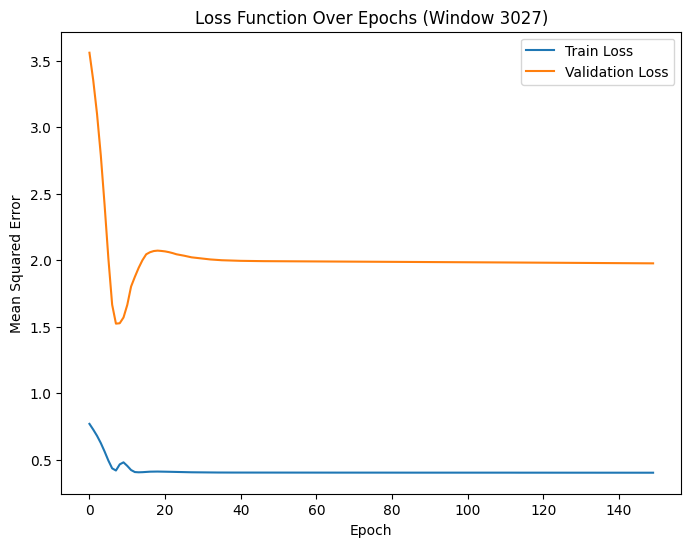

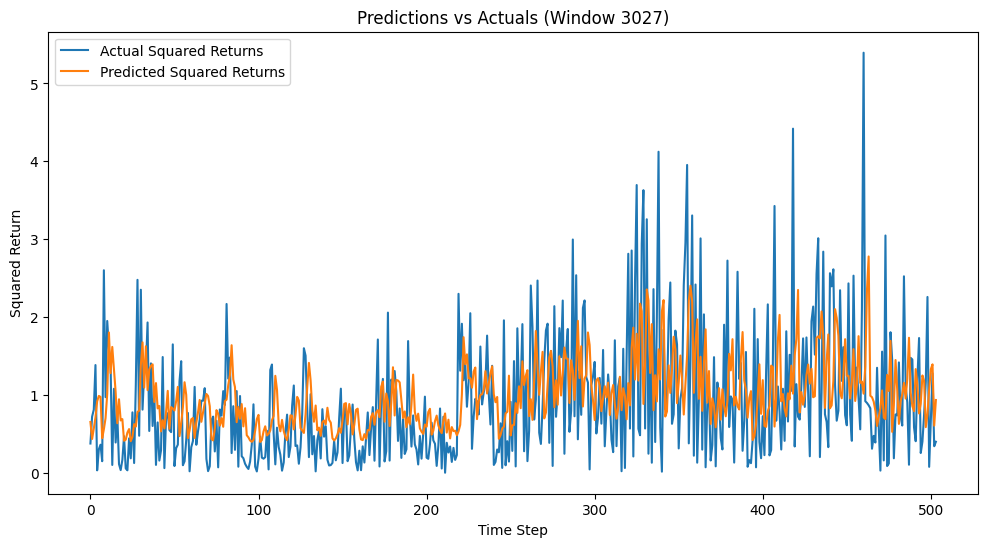

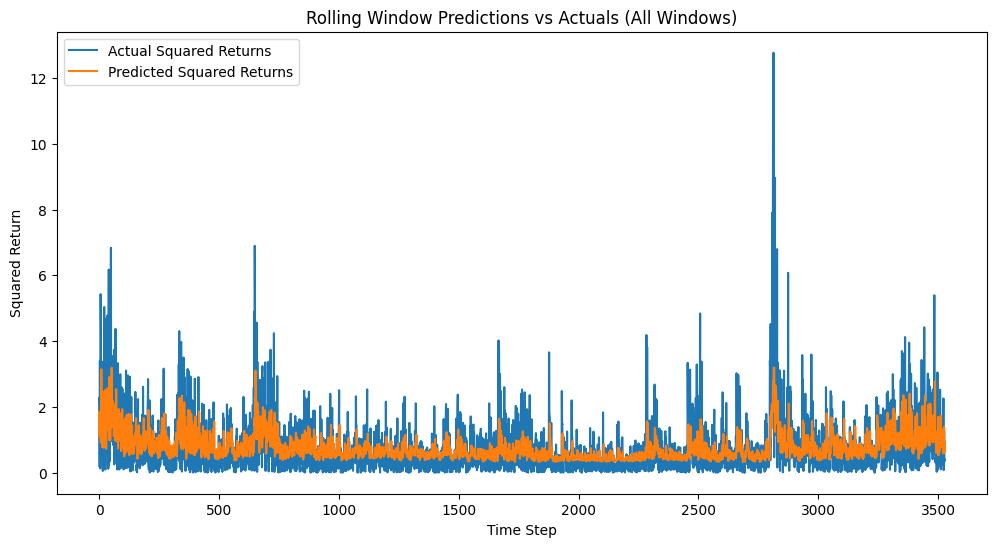

   start_index       MSE       MAE
0            3  1.015885  0.748538
1          507  0.654537  0.592937
2         1011  0.216035  0.368373
3         1515  0.362828  0.442387
4         2019  0.366432  0.414746
5         2523  1.248763  0.597613
6         3027  0.681334  0.633778


In [ ]:
initializer = initializers.GlorotUniform(seed=0)

X_raw = np.abs(merged_df['log_return'].values)  # Predictor
y_raw = merged_df['Realized_Volatility'].values  # Target

lookback = 3  
n_features = 1  # Univariate input

# Split sequence into samples 
def split_sequence(sequence_x, sequence_y, n_steps):
    X, y = [], []
    for i in range(len(sequence_x)):
        end_ix = i + n_steps
        if end_ix > len(sequence_x) - 1:
            break
        seq_x = sequence_x[i:end_ix]
        seq_y = sequence_y[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X).reshape(-1, n_steps, n_features), np.array(y).reshape(-1, 1)

# Define window sizes 
train_size = 1008  # 
window_size = 504  # Test size
total_size = train_size + window_size
total_sequences = len(data)

# Lists to store results
all_predictions, all_actuals, window_metrics = [], [], []

# Rolling window loop
start_indices = range(lookback, total_sequences - total_size + 1, window_size)
for start in start_indices:
    # Define indices for rolling window
    train_idx_start = start
    train_idx_end = start + train_size
    test_idx_end = start + total_size

    # Extract data for this window
    train_data_x = X_raw[train_idx_start:train_idx_end]
    train_data_y = y_raw[train_idx_start:train_idx_end]
    test_data_x = X_raw[train_idx_end - lookback:test_idx_end]
    test_data_y = y_raw[train_idx_end - lookback:test_idx_end]

    # Create sequences
    X_train, y_train = split_sequence(train_data_x, train_data_y, lookback)
    X_test, y_test = split_sequence(test_data_x, test_data_y, lookback)

    X_train_scaled = X_train
    y_train_scaled = y_train
    X_test_scaled = X_test
    y_test_scaled = y_test

    # Optimized LSTM Model 
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(128, activation='tanh', kernel_regularizer=l2(0.0001), return_sequences=True),
        Dropout(0.0005),
        LSTM(512, activation='tanh', kernel_regularizer=l2(0.0001), return_sequences=True),
        Dropout(0.0005),
        LSTM(128, activation='tanh', kernel_regularizer=l2(0.0001)),
        Dropout(0.0005),
        Dense(1, activation='linear')
    ])

    optimizer = Adam(learning_rate=0.001, clipnorm=0.5)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.MeanAbsoluteError()]
    )

    # Callbacks
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
    checkpoint_filepath = f'best_model_window_{start}.h5'
    checkpoint = ModelCheckpoint(
        checkpoint_filepath,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=0
    )

    # Train the Model 
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=150,
        batch_size=3000,
        validation_split=0.3333,
        callbacks=[lr_scheduler, checkpoint],
        verbose=0
    )

    # Load Best Model
    model = load_model(checkpoint_filepath, compile=False)
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=0.5),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.MeanAbsoluteError()]
    )

    # Predict on Test Set 
    y_pred = model.predict(X_test_scaled, verbose=0)
    y_true = y_test_scaled

    all_predictions.append(y_pred)
    all_actuals.append(y_true)

    mse_window = mean_squared_error(y_true, y_pred)
    mae_window = mean_absolute_error(y_true, y_pred)
    window_metrics.append({'start_index': start, 'MSE': mse_window, 'MAE': mae_window})

    print(f"Window {start}: MSE = {mse_window:.6f}, MAE = {mae_window:.6f}")

    # Plot Loss for This Window
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Function Over Epochs (Window {start})')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.show()

    # Plot Predictions vs Actuals for This Window
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='Actual Squared Returns')
    plt.plot(y_pred, label='Predicted Squared Returns')
    plt.title(f'Predictions vs Actuals (Window {start})')
    plt.xlabel('Time Step')
    plt.ylabel('Squared Return')
    plt.legend()
    plt.show()

# Combine all predictions
all_predictions = np.concatenate(all_predictions, axis=0)
all_actuals = np.concatenate(all_actuals, axis=0)

# lot Combined Predictions vs Actuals
plt.figure(figsize=(12, 6))
plt.plot(all_actuals, label='Actual Squared Returns')
plt.plot(all_predictions, label='Predicted Squared Returns')
plt.title('Rolling Window Predictions vs Actuals (All Windows)')
plt.xlabel('Time Step')
plt.ylabel('Squared Return')
plt.legend()
plt.show()

# Display Metrics
metrics_df = pd.DataFrame(window_metrics)
print(metrics_df)

# LSTM pediction Graph with dates 

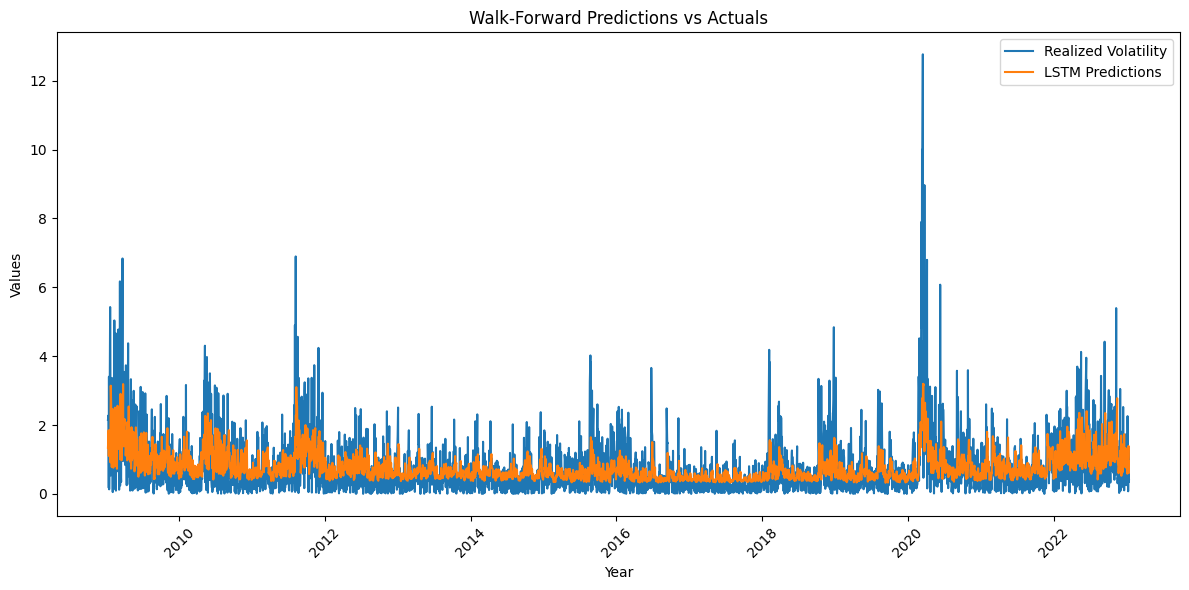

In [ ]:

date_column = None
possible_date_columns = ['date', 'Date', 'DATE', 'time', 'Time']  
for col in possible_date_columns:
    if col in merged_df.columns:
        date_column = col
        break

if date_column is None:
    raise ValueError("No date column found in merged_df. Available columns: " + str(list(merged_df.columns)) +
                     ". Please specify the date column name or add a 'date' column.")

# Convert date column to datetime
try:
    dates = pd.to_datetime(merged_df[date_column])
except ValueError as e:
    raise ValueError(f"Could not convert '{date_column}' to datetime. Ensure it's in a valid date format. Error: {e}")

# Reconstruct test set dates corresponding to predictions 
lookback = 3
train_size = 1008
window_size = 504
total_size = train_size + window_size
total_sequences = len(merged_df)

# List to store test set dates
test_dates = []

# Rolling window loop to collect test set dates 
start_indices = range(lookback, total_sequences - total_size + 1, window_size)
for start in start_indices:
    # Define indices for the test set
    train_idx_end = start + train_size
    test_idx_end = start + total_size
    # Get dates for the test set predictions (accounting for sequence length)
    test_window_dates = dates[train_idx_end:test_idx_end][-window_size:]
    test_dates.append(test_window_dates)

# Combine test dates 
test_dates = np.concatenate(test_dates, axis=0)

#  Verify lengths match 
if len(test_dates) != len(all_predictions):
    raise ValueError(f"Length mismatch: test_dates ({len(test_dates)}) vs all_predictions ({len(all_predictions)})")

# Create results DataFrame 
results_df = pd.DataFrame({
    'date': pd.to_datetime(test_dates),  # Ensure datetime format
    'actual': all_actuals.flatten(),
    'predicted': all_predictions.flatten()
})

# Plot the results in the same style 
plt.figure(figsize=(12, 6))
plt.plot(results_df['date'], results_df['actual'], label='Realized Volatility')
plt.plot(results_df['date'], results_df['predicted'], label='LSTM Predictions')
plt.title('Walk-Forward Predictions vs Actuals')
plt.xlabel('Year')
plt.ylabel('Values')
plt.legend()

# Format x-axis to display only the year
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph with lstm and garch predictions

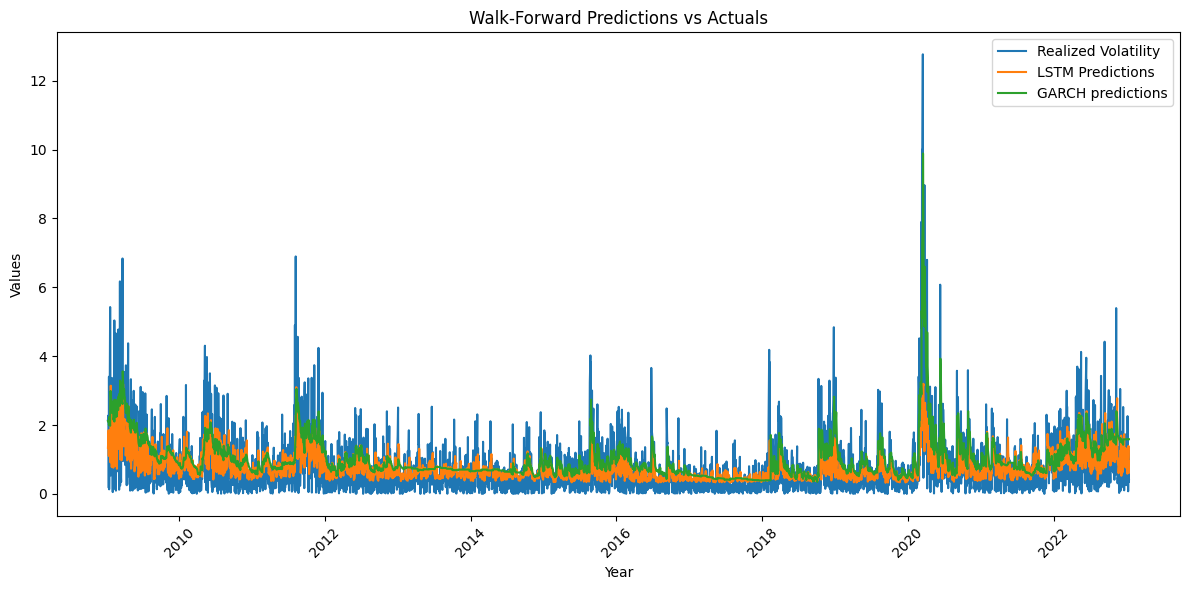

In [ ]:

date_column = None
possible_date_columns = ['date', 'Date', 'DATE', 'time', 'Time'] 
for col in possible_date_columns:
    if col in merged_df.columns:
        date_column = col
        break

if date_column is None:
    raise ValueError("No date column found in merged_df. Available columns: " + str(list(merged_df.columns)) +
                     ". Please specify the date column name or add a 'date' column.")

# Convert date column to datetime
try:
    dates = pd.to_datetime(merged_df[date_column])
except ValueError as e:
    raise ValueError(f"Could not convert '{date_column}' to datetime. Ensure it's in a valid date format. Error: {e}")

# Validate garch_vol column
if 'garch_vol' not in merged_df.columns:
    raise ValueError("Column 'garch_vol' not found in merged_df. Available columns: " + str(list(merged_df.columns)))

# Reconstruct test set dates corresponding to predictions 
lookback = 3
train_size = 1008
window_size = 504
total_size = train_size + window_size
total_sequences = len(merged_df)

# Lists to store test set dates and corresponding garch_vol values
test_dates = []
test_garch_vol = []

# Rolling window loop to collect test set dates and garch_vol 
start_indices = range(lookback, total_sequences - total_size + 1, window_size)
for start in start_indices:
    # Define indices for the test set
    train_idx_end = start + train_size
    test_idx_end = start + total_size
    # Get dates and garch_vol for the test set predictions
    test_window_dates = dates[train_idx_end:test_idx_end][-window_size:]
    test_window_garch = merged_df['garch_vol'].values[train_idx_end:test_idx_end][-window_size:]
    test_dates.append(test_window_dates)
    test_garch_vol.append(test_window_garch)

# Combine test dates and garch_vol
test_dates = np.concatenate(test_dates, axis=0)
test_garch_vol = np.concatenate(test_garch_vol, axis=0)

# Verify lengths match 
if len(test_dates) != len(all_predictions):
    raise ValueError(f"Length mismatch: test_dates ({len(test_dates)}) vs all_predictions ({len(all_predictions)})")
if len(test_garch_vol) != len(all_predictions):
    raise ValueError(f"Length mismatch: test_garch_vol ({len(test_garch_vol)}) vs all_predictions ({len(all_predictions)})")

# Create results DataFrame 
results_df = pd.DataFrame({
    'date': pd.to_datetime(test_dates),  # Ensure datetime format
    'actual': all_actuals.flatten(),
    'predicted': all_predictions.flatten(),
    'garch': test_garch_vol
})

# Plot the results in the same style 
plt.figure(figsize=(12, 6))
plt.plot(results_df['date'], results_df['actual'], label='Realized Volatility')
plt.plot(results_df['date'], results_df['predicted'], label='LSTM Predictions')
plt.plot(results_df['date'], results_df['garch'], label='GARCH predictions')
plt.title('Walk-Forward Predictions vs Actuals')
plt.xlabel('Year')
plt.ylabel('Values')
plt.legend()

# Format x-axis to display only the year
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Metrics calculation for both models and barplot 

In [ ]:
# Compute MSE, RMSE, MAE, and HMSE for 'lstm_vol' vs 'Actual'
mse_lstm = mean_squared_error(results_df['actual'], results_df['predicted'])
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(results_df['actual'], results_df['predicted'])
variance_actual = np.var(results_df['actual'])
hmse_lstm = np.mean((results_df['actual'] - results_df['predicted']) ** 2 / variance_actual)

# Compute MSE, RMSE, MAE, and HMSE for 'garch_vol' vs 'Actual'
mse_garch = mean_squared_error(results_df['actual'], results_df['garch'])
rmse_garch = np.sqrt(mse_garch)
mae_garch = mean_absolute_error(results_df['actual'], results_df['garch'])
hmse_garch = np.mean((results_df['actual'] - results_df['garch']) ** 2 / variance_actual)

# Create DataFrame for results
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'HMSE'],
    'LSTM Vol vs Actual': [mse_lstm, rmse_lstm, mae_lstm, hmse_lstm],
    'GARCH Vol vs Actual': [mse_garch, rmse_garch, mae_garch, hmse_garch]
})

# Display results
print(metrics_df)
results_df.head()

  Metric  LSTM Vol vs Actual  GARCH Vol vs Actual
0    MSE            0.649402             0.659557
1   RMSE            0.805855             0.812131
2    MAE            0.542625             0.597830
3   HMSE            0.824929             0.837829


,date,actual,predicted,garch
0,2009-01-09,2.153321,1.340993,2.109644
1,2009-01-12,2.282259,1.846648,2.113287
2,2009-01-13,0.175652,1.103036,2.133865
3,2009-01-14,3.403246,1.748791,1.998696
4,2009-01-15,0.132830,1.587135,2.232393


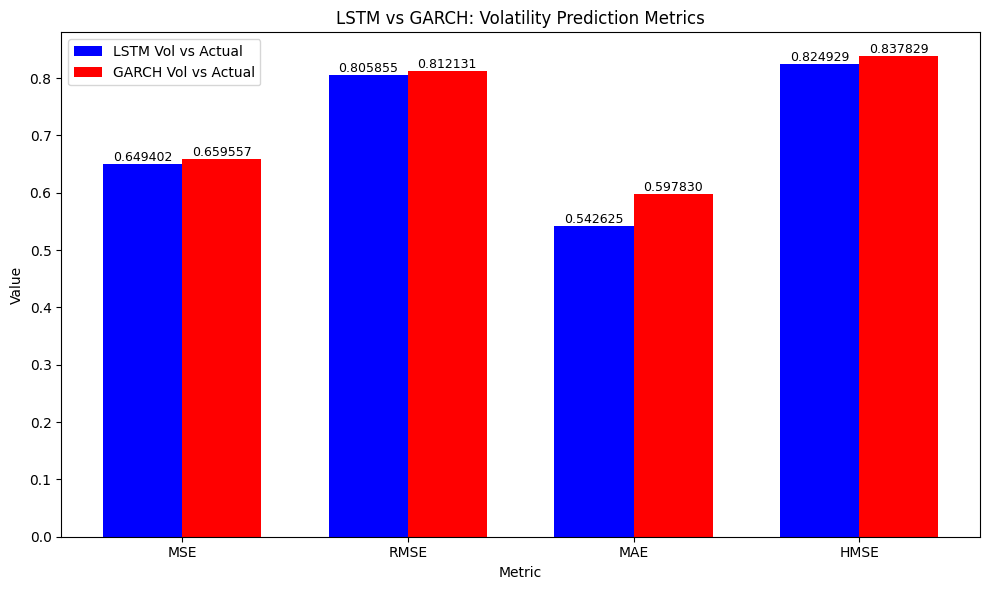

In [ ]:
# Validate metrics_df structure
required_columns = ['Metric', 'LSTM Vol vs Actual', 'GARCH Vol vs Actual']
if not all(col in metrics_df.columns for col in required_columns):
    raise ValueError(f"metrics_df must contain columns: {required_columns}. Found: {list(metrics_df.columns)}")

# Set up the bar plot 
fig, ax = plt.subplots(figsize=(10, 6))

# Define bar width and positions
bar_width = 0.35
x = np.arange(len(metrics_df['Metric']))

# Plot bars
bars1 = ax.bar(x - bar_width/2, metrics_df['LSTM Vol vs Actual'], bar_width, label='LSTM Vol vs Actual', color='blue')
bars2 = ax.bar(x + bar_width/2, metrics_df['GARCH Vol vs Actual'], bar_width, label='GARCH Vol vs Actual', color='red')

# Customize the plot
ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_title('LSTM vs GARCH: Volatility Prediction Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Metric'])
ax.legend()

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.6f}', 
            ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.6f}', 
            ha='center', va='bottom', fontsize=9)

# Adjust layout for readability
plt.tight_layout()
plt.show()

## Ensemble method: For each rolling window, compute the MAE of the LSTM and GARCH forecasts over the most recent windows, assign weights inversely proportional to these errors (with equal weights for the first window), and then form the ensemble forecast as the weighted average of the two models’ predictions.

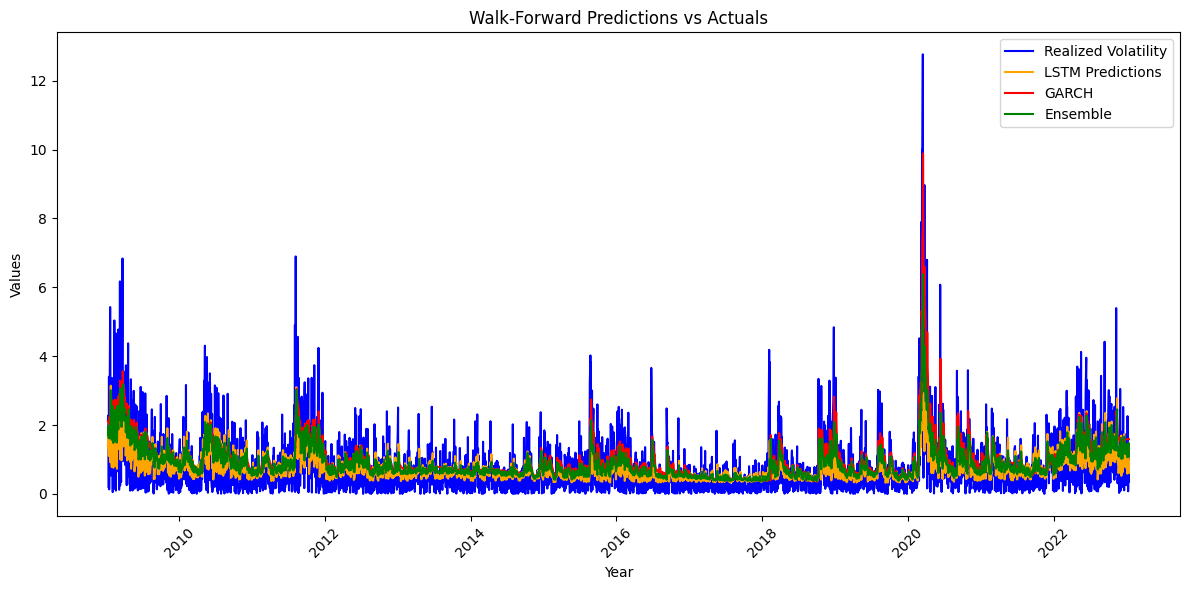


Metrics Summary:
  Metric  LSTM Vol vs Actual  GARCH Vol vs Actual  Ensemble Vol vs Actual
0    MSE            0.649402             0.659557                0.596512
1    MAE            0.542625             0.597830                0.553222

Per-Window Weights:
   window_idx    w_lstm   w_garch
0           0  0.500000  0.500000
1           1  0.518462  0.481538
2           2  0.521850  0.478150
3           3  0.528477  0.471523
4           4  0.522678  0.477322
5           5  0.522718  0.477282
6           6  0.522452  0.477548


In [ ]:
# Validate results_df structure 
required_columns = ['date', 'actual', 'predicted', 'garch']
if not all(col in results_df.columns for col in required_columns):
    raise ValueError(f"results_df must contain columns: {required_columns}. Found: {list(results_df.columns)}")

# Ensure date column is datetime
results_df['date'] = pd.to_datetime(results_df['date'])

# Reconstruct rolling window structure
window_size = 504  # Test size from your model
lookback = 3
train_size = 1008
total_sequences = len(results_df) + window_size * (len(results_df) // window_size)  # Approximate total data length
n_windows = len(results_df) // window_size  # Number of windows based on results_df

# Lists to store per-window metrics and weights
window_metrics = []
window_weights = []
ensemble_predictions = []

# Rolling window loop to compute weights and ensemble predictions 
for window_idx in range(n_windows):
    # Define test set indices for this window
    start_idx = window_idx * window_size
    end_idx = start_idx + window_size
    
    # Extract test set data
    window_df = results_df.iloc[start_idx:end_idx]
    if len(window_df) < window_size:
        print(f"Warning: Window {window_idx} has {len(window_df)} rows, expected {window_size}. Skipping.")
        continue
    
    y_true = window_df['actual'].values
    y_lstm = window_df['predicted'].values
    y_garch = window_df['garch'].values

    # === Compute MAEs for this window ===
    mae_lstm = mean_absolute_error(y_true, y_lstm)
    mae_garch = mean_absolute_error(y_true, y_garch)

    # === Store metrics for this window ===
    mse_lstm = mean_squared_error(y_true, y_lstm)
    mse_garch = mean_squared_error(y_true, y_garch)
    window_metrics.append({
        'window_idx': window_idx,
        'MAE_LSTM': mae_lstm,
        'MAE_GARCH': mae_garch,
        'MSE_LSTM': mse_lstm,
        'MSE_GARCH': mse_garch
    })

    # Calculate weights using rolling MAEs (k=2)
    if window_idx == 0:
        # First window: use equal weights
        w_lstm = 0.5
        w_garch = 0.5
    else:
        # Use last k=2 windows (or all available if < 2)
        k = min(2, window_idx)
        recent_metrics = window_metrics[-k:]
        avg_mae_lstm = np.mean([m['MAE_LSTM'] for m in recent_metrics])
        avg_mae_garch = np.mean([m['MAE_GARCH'] for m in recent_metrics])
        
        # Inverse error weighting
        total_error = avg_mae_lstm + avg_mae_garch
        if total_error == 0:  # Avoid division by zero
            w_lstm = 0.5
            w_garch = 0.5
        else:
            w_lstm = avg_mae_garch / total_error
            w_garch = avg_mae_lstm / total_error

    window_weights.append({
        'window_idx': window_idx,
        'w_lstm': w_lstm,
        'w_garch': w_garch
    })

    # Compute ensemble predictions 
    y_ensemble = w_lstm * y_lstm + w_garch * y_garch
    ensemble_predictions.append(y_ensemble)

    # Compute ensemble metrics 
    mae_ensemble = mean_absolute_error(y_true, y_ensemble)
    mse_ensemble = mean_squared_error(y_true, y_ensemble)
    window_metrics[-1].update({
        'MAE_Ensemble': mae_ensemble,
        'MSE_Ensemble': mse_ensemble
    })

# Combine ensemble predictions 
ensemble_predictions = np.concatenate(ensemble_predictions, axis=0)

# Update results_df with ensemble predictions
results_df['ensemble'] = ensemble_predictions

# Create metrics_df 
metrics_summary = pd.DataFrame({
    'Metric': ['MSE', 'MAE'],
    'LSTM Vol vs Actual': [
        np.mean([m['MSE_LSTM'] for m in window_metrics]),
        np.mean([m['MAE_LSTM'] for m in window_metrics])
    ],
    'GARCH Vol vs Actual': [
        np.mean([m['MSE_GARCH'] for m in window_metrics]),
        np.mean([m['MAE_GARCH'] for m in window_metrics])
    ],
    'Ensemble Vol vs Actual': [
        np.mean([m['MSE_Ensemble'] for m in window_metrics]),
        np.mean([m['MAE_Ensemble'] for m in window_metrics])
    ]
})

# Plot the results 
plt.figure(figsize=(12, 6))
plt.plot(results_df['date'], results_df['actual'], label='Realized Volatility', color='blue')
plt.plot(results_df['date'], results_df['predicted'], label='LSTM Predictions', color='orange')
plt.plot(results_df['date'], results_df['garch'], label='GARCH', color='red')
plt.plot(results_df['date'], results_df['ensemble'], label='Ensemble', color='green')
plt.title('Walk-Forward Predictions vs Actuals')
plt.xlabel('Year')
plt.ylabel('Values')
plt.legend()

# Format x-axis to display only the year
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display metrics and weights 
print("\nMetrics Summary:")
print(metrics_summary)

print("\nPer-Window Weights:")
weights_df = pd.DataFrame(window_weights)
print(weights_df)

# Metrics for all three and barplot

In [ ]:
# Compute MSE, RMSE, MAE, and HMSE for 'lstm_vol' vs 'Actual'
mse_lstm = mean_squared_error(results_df['actual'], results_df['predicted'])
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(results_df['actual'], results_df['predicted'])
variance_actual = np.var(results_df['actual'])
hmse_lstm = np.mean((results_df['actual'] - results_df['predicted']) ** 2 / variance_actual)

# Compute MSE, RMSE, MAE, and HMSE for 'garch_vol' vs 'Actual'
mse_garch = mean_squared_error(results_df['actual'], results_df['garch'])
rmse_garch = np.sqrt(mse_garch)
mae_garch = mean_absolute_error(results_df['actual'], results_df['garch'])
hmse_garch = np.mean((results_df['actual'] - results_df['garch']) ** 2 / variance_actual)

# Compute MSE, RMSE, MAE, and HMSE for 'garch_vol' vs 'Actual'
mse_ensemble = mean_squared_error(results_df['actual'], results_df['ensemble'])
rmse_ensemble = np.sqrt(mse_ensemble)
mae_ensemble = mean_absolute_error(results_df['actual'], results_df['ensemble'])
hmse_ensemble = np.mean((results_df['actual'] - results_df['ensemble']) ** 2 / variance_actual)

# Create DataFrame for results
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'HMSE'],
    'LSTM Vol vs Actual': [mse_lstm, rmse_lstm, mae_lstm, hmse_lstm],
    'GARCH Vol vs Actual': [mse_garch, rmse_garch, mae_garch, hmse_garch],
    'Ensemble vs Actual': [mse_ensemble, rmse_ensemble, mae_ensemble, hmse_ensemble]
})

# Display results
print(metrics_df)
results_df.head()

  Metric  LSTM Vol vs Actual  GARCH Vol vs Actual  Ensemble vs Actual
0    MSE            0.649402             0.659557            0.596512
1   RMSE            0.805855             0.812131            0.772342
2    MAE            0.542625             0.597830            0.553222
3   HMSE            0.824929             0.837829            0.757744


,date,actual,predicted,garch,ensemble
0,2009-01-09,2.153321,1.340993,2.109644,1.725318
1,2009-01-12,2.282259,1.846648,2.113287,1.979967
2,2009-01-13,0.175652,1.103036,2.133865,1.618451
3,2009-01-14,3.403246,1.748791,1.998696,1.873743
4,2009-01-15,0.132830,1.587135,2.232393,1.909764


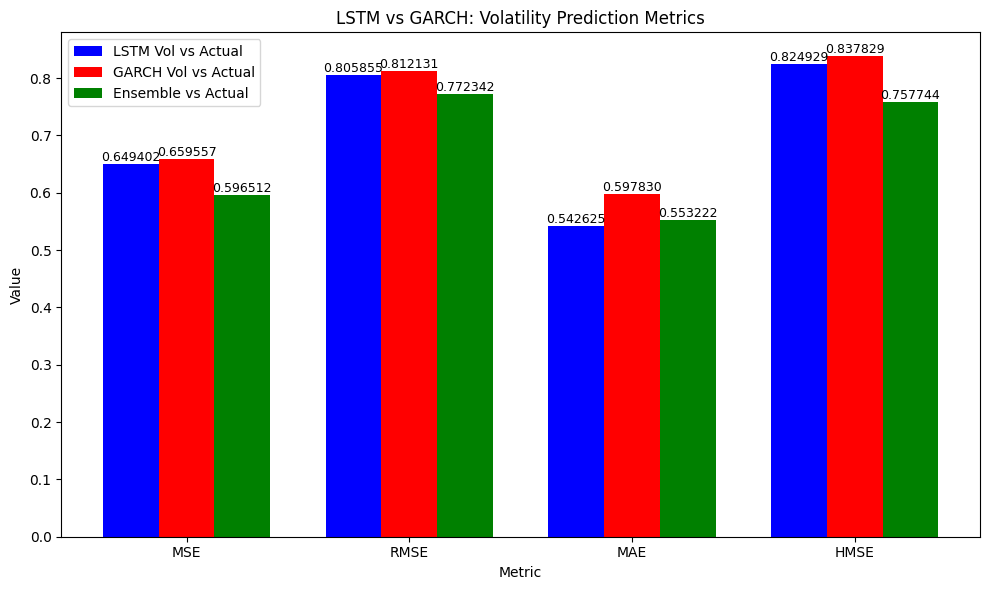

In [ ]:
# Validate metrics_df structure
required_columns = ['Metric', 'LSTM Vol vs Actual', 'GARCH Vol vs Actual', 'Ensemble vs Actual']
if not all(col in metrics_df.columns for col in required_columns):
    raise ValueError(f"metrics_df must contain columns: {required_columns}. Found: {list(metrics_df.columns)}")

# Set up the bar plot 
fig, ax = plt.subplots(figsize=(10, 6))

# Define bar width and positions
bar_width = 0.25
x = np.arange(len(metrics_df['Metric']))

# Plot bars at correctly offset positions
bars1 = ax.bar(x - bar_width, metrics_df['LSTM Vol vs Actual'], bar_width, label='LSTM Vol vs Actual', color='blue')
bars2 = ax.bar(x, metrics_df['GARCH Vol vs Actual'], bar_width, label='GARCH Vol vs Actual', color='red')
bars3 = ax.bar(x + bar_width, metrics_df['Ensemble vs Actual'], bar_width, label='Ensemble vs Actual', color='green')

# Customize the plot
ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.set_title('LSTM vs GARCH: Volatility Prediction Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Metric'])
ax.legend()

# Add value labels on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.6f}', 
                ha='center', va='bottom', fontsize=9)

# Adjust layout for readability
plt.tight_layout()
plt.show()


In [23]:
actual_returns = merged_df[['date', 'log_return']]
actual_returns['date'] = pd.to_datetime(actual_returns['date'])
results_df = pd.merge(results_df, actual_returns, on='date', how='left')

/var/folders/g3/d8cr9sbj1nq0g6fwxyhphc380000gn/T/ipykernel_74803/2323404573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  actual_returns['date'] = pd.to_datetime(actual_returns['date'])


# VaR and ES estimation graph, Kupiec, Christopher tests

The Kupiec Test checks whether the number of VaR breaches matches the expected frequency.

Null Hypothesis (H₀): The number of breaches is correct.

All models - LSTM, GARCH, and Ensemble - fail this test (p-value = 0.000), meaning they produce too many or too few breaches, indicating poor unconditional coverage.

The Christoffersen Test evaluates both the frequency and independence (timing) of breaches.

Null Hypothesis (H₀): Breaches are correctly timed and occur independently.

LSTM fails this test (p = 0.005), suggesting that its breaches are clustered or poorly timed.

GARCH and Ensemble pass (p > 0.5), indicating their breaches occur independently and are well-timed, despite the wrong number of breaches.

In summary:

LSTM fails both tests - poor frequency and clustering of breaches.

GARCH and Ensemble fail Kupiec but pass Christoffersen - breach timing is acceptable, but frequency is inaccurate.

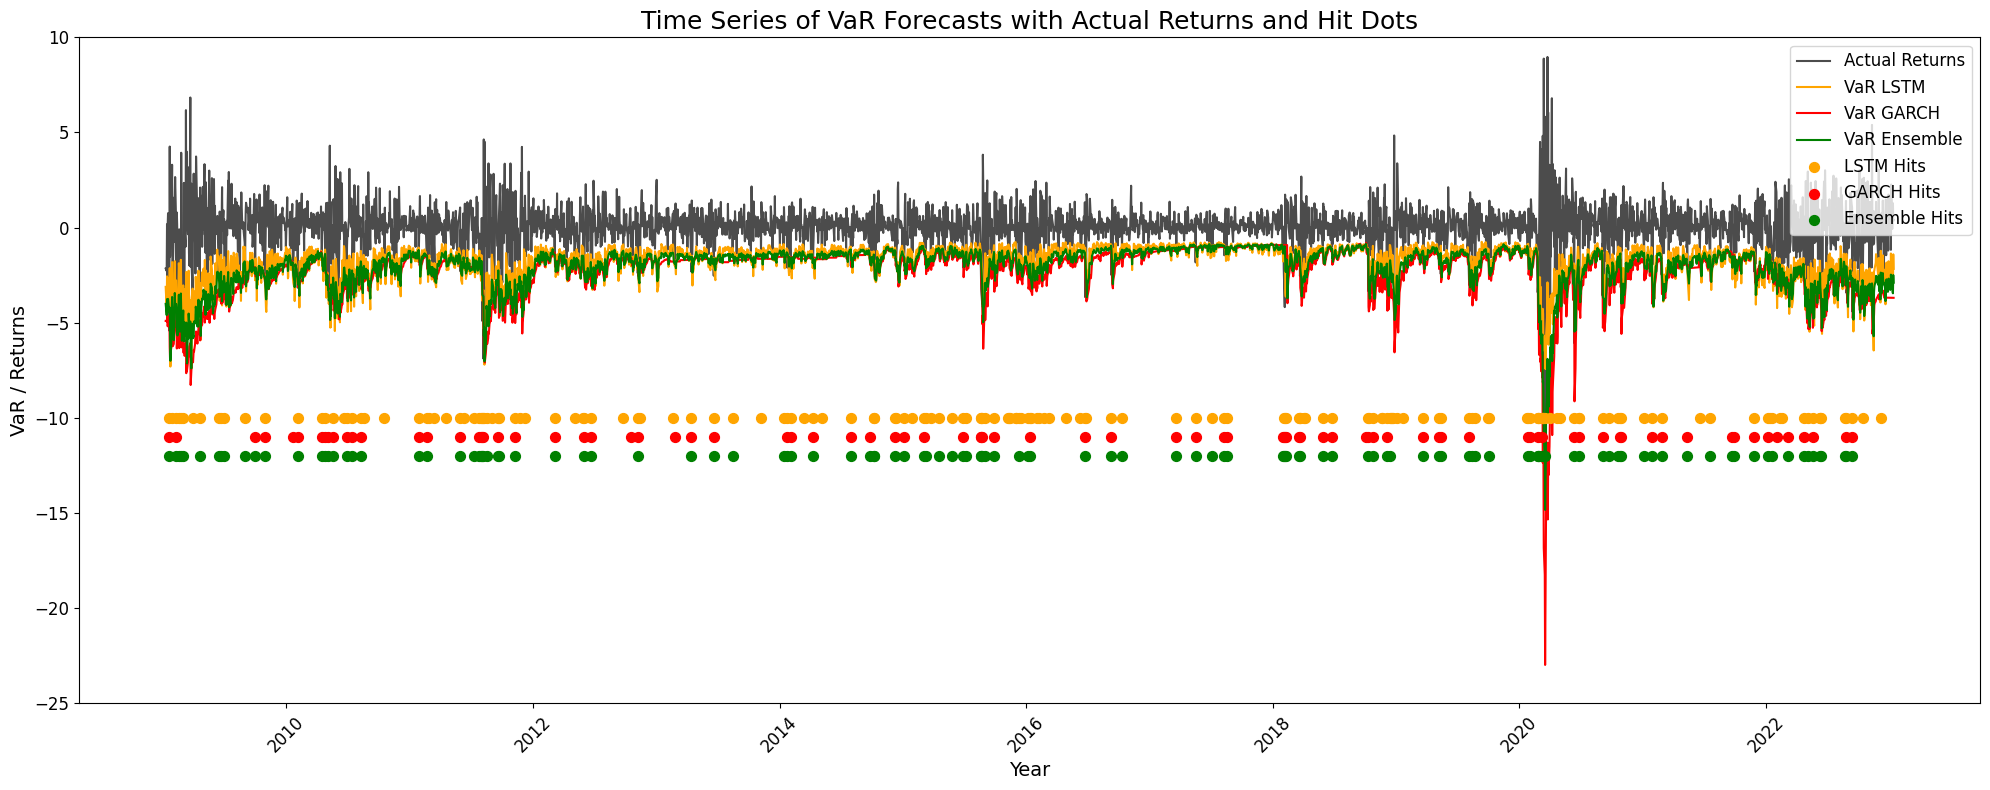

In [ ]:
# Plot: VaR Time Series with Actual Returns and Horizontally-Aligned Hit Markers
plt.figure(figsize=(20, 8))

# Plot lines
plt.plot(results_df['date'], results_df['log_return'], label='Actual Returns', color='black', alpha=0.7)
plt.plot(results_df['date'], results_df['VaR_lstm'], label='VaR LSTM', color='orange')
plt.plot(results_df['date'], results_df['VaR_garch'], label='VaR GARCH', color='red')
plt.plot(results_df['date'], results_df['VaR_ensemble'], label='VaR Ensemble', color='green')

# Y-positions for aligned hit dots
y_lstm = -10
y_garch = -11
y_ensemble = -12

# Add horizontal hit dots
plt.scatter(results_df.loc[results_df['hit_lstm'] == 1, 'date'],
            [y_lstm] * results_df['hit_lstm'].sum(),
            color='orange', s=50, label='LSTM Hits', zorder=5)

plt.scatter(results_df.loc[results_df['hit_garch'] == 1, 'date'],
            [y_garch] * results_df['hit_garch'].sum(),
            color='red', s=50, label='GARCH Hits', zorder=5)

plt.scatter(results_df.loc[results_df['hit_ensemble'] == 1, 'date'],
            [y_ensemble] * results_df['hit_ensemble'].sum(),
            color='green', s=50, label='Ensemble Hits', zorder=5)

# Labels and formatting (with bigger fonts)
plt.title('Time Series of VaR Forecasts with Actual Returns and Hit Dots', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('VaR / Returns', fontsize=14)
plt.legend(fontsize=12, loc='upper right')  # Change loc if legend overlaps

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(-25, 10)
plt.tight_layout()
plt.show()
